# Reconstruction and Standardization of Fragmented Raw Acquisition Outputs

### Overview

The acquisition layer established in the previous stage preserved measurement signals and behavioral events in a traceable raw format, but the resulting outputs were still fragmented across trial-wise files. Because that structure prioritized robustness during recording, the next requirement was to reconstruct those outputs into a continuous session-level representation.

This stage therefore served as the reconstruction and standardization layer of the workflow. Its role was to convert fragmented acquisition-stage outputs into a structured dataset that could support later quantification, signal validation, correction, and repeated analysis across sessions.

### Why Fragmented Acquisition Outputs Required Reconstruction

The acquisition workflow was intentionally designed to preserve data even when recordings were interrupted or divided into trial-wise segments. This design improved robustness at the measurement stage, but it also meant that the raw outputs could not be interpreted directly as continuous session-level signals.

Before filtering, event alignment, or comparison could begin, the fragmented outputs had to be reconstructed into a unified temporal structure. Without that step, downstream analysis would depend on manual restoration of timing relationships across multiple raw files, reducing reproducibility and increasing processing burden.

The central task of this stage was therefore not simple preprocessing, but restoration of continuity, preservation of temporal order, and conversion of fragmented acquisition outputs into a reusable session-level dataset.

### Reconstruction Logic and Processing Rules

To ensure that reconstruction was performed consistently across recordings, the preprocessing rules were defined in advance at the pipeline level. Sampling rate, downsampling settings, event thresholds, and analysis windows were specified before transformation so that the same reconstruction logic could be applied across trials and sessions.

This rule-based structure was important because the goal of the pipeline was not one-time file conversion, but standardized regeneration of session-level datasets from fragmented raw acquisition outputs.


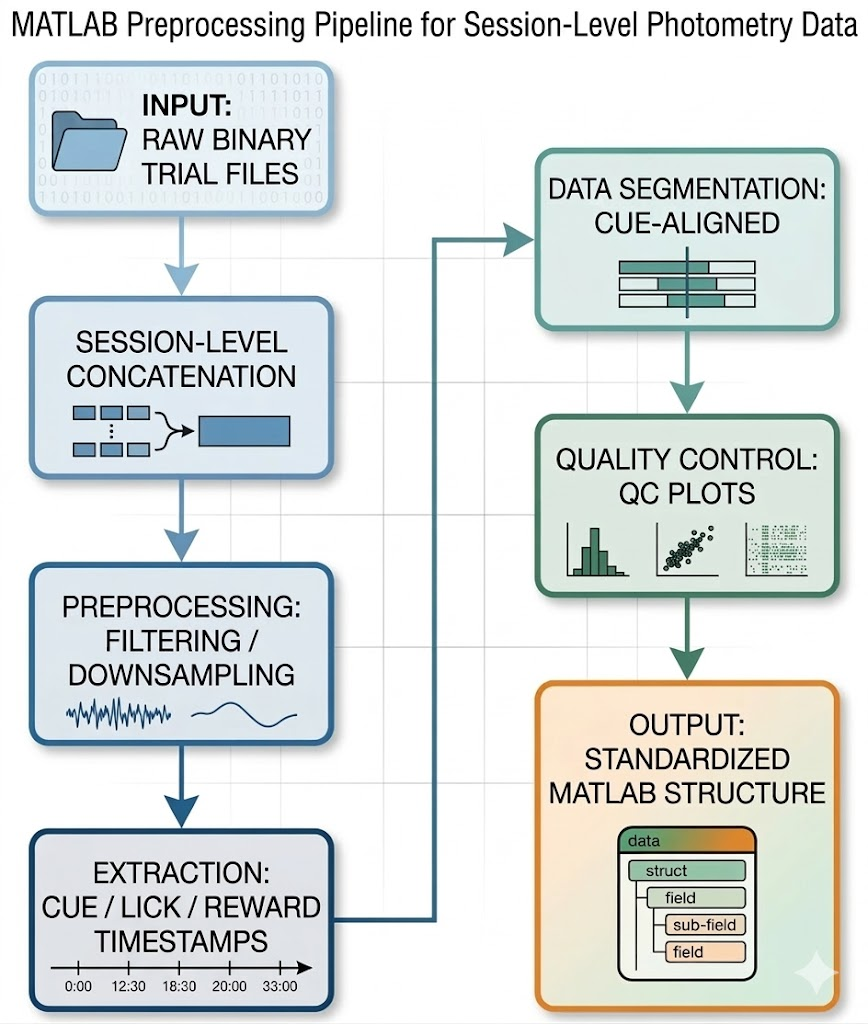

In [8]:
from pathlib import Path
from IPython.display import display, HTML
import base64

NOTEBOOK_DIR = Path.cwd()
ASSET_DIR = NOTEBOOK_DIR.parent / "assets" / "figures"
image_path = ASSET_DIR / "dataprocess.jpg"

with open(image_path, "rb") as f:
    encoded = base64.b64encode(f.read()).decode("utf-8")

display(HTML(f"""
<div style="display:flex; justify-content:center; width:100%;">
    <img src="data:image/jpeg;base64,{encoded}" style="width:500px; display:block;">
</div>
"""))

**Figure 1.** MATLAB-based reconstruction pipeline for converting fragmented trial-wise acquisition outputs into a continuous session-level dataset.

The pipeline illustrates how acquisition-stage raw outputs were transformed through reconstruction, signal conditioning, event standardization, and dataset organization into a reusable session-level structure.

In [ ]:
# Define shared reconstruction parameters and preprocessing rules
# These parameters ensure that fragmented trial-wise outputs are converted
# into session-level data using a consistent transformation logic.

trialList              = 1:1000;
photometryScale        = 10000;      # Scaling factor for photometry channels
eventScale             = 4096;       # Scaling factor for behavioral event channels
motionScale            = 4096;       # Scaling factor for motion channel
rawFs                  = 10000;      # Original event sampling rate (Hz)
velocityFs             = 50;         # Velocity signal sampling rate after downsampling (Hz)
minPeakDistanceSamples = rawFs/10;   # Min peak distance (0.1 sec, eliminates values above 10 Hz)
eventThreshold         = 3.2;        # Detection threshold for behavioral event channels (V)
laserThreshold         = 3.2;        # Laser detection threshold
preEventWindowSec      = 2;          # seconds before cue event
postEventWindowSec     = 6;          # seconds after cue event
lickBinSize            = 0.05;       # lick rate bin size (sec)
lickTimeBins           = -preEventWindowSec:lickBinSize:postEventWindowSec;
downsampleFactor       = 5;                         # Photometry downsample factor
downsampledFs          = rawFs / downsampleFactor;  # Photometry new sampling rate
motionDCOffset         = 2500;
motionAdcScale         = 1000;
velocityCalibration    = 9e-4;       # Velocity calibration (m/s)
velocityTimeAxis       = -preEventWindowSec:(1/velocityFs):postEventWindowSec;
maxCueRewardDelay      = 6;          # Max Cue-reward Delay (sec)
minLickRateHz          = 4;          # Min lick rate in lick episode (Hz)
minLickEpisodeGapSec   = 5;          # Min lick episode gap (sec)
doFilterFlag           = 'y';        # Applying photometry filtering
lowpassCutoffHz        = 10;         # Low pass cutoff (Hz)
filterOrder            = 3; 


### Session Reconstruction and Signal Conditioning

The first operational step of the pipeline was to reconstruct segmented trial-wise outputs into a single continuous session. Signal streams and event channels were concatenated in temporal order so that the measurement record could be interpreted as a coherent session rather than as isolated raw fragments.

Once continuity had been restored, the main signal channels were conditioned through filtering and downsampling. This step reduced noise, simplified later computations, and prepared the reconstructed session for event-aligned segmentation and comparison.

Optional baseline correction was also included so that slow session-level baseline changes could be addressed when necessary without altering the reconstruction logic itself.

In [ ]:
# Reconstruct a continuous session by concatenating trial-wise raw files
# Each channel is restored in temporal order so that downstream processing
# can operate on a unified session-level representation.

lickSignalRaw    = [];
cue1SignalRaw    = []; 
cue2SignalRaw    = []; 
cue3SignalRaw    = []; 
cue4SignalRaw    = []; 
reward1SignalRaw = []; 
reward2SignalRaw = [];
laserSignalRaw   = [];
airpuffSignalRaw = [];
motionYDecimated = [];
specChan1Raw     = [];
specChan2Raw     = [];

for trialIdx = 1:length(trialList)
    trialNum    = trialList(trialIdx);
    
    if trialNum < 10
        trialString = ['0' num2str(trialNum)];
    else
        trialString = num2str(trialNum);
    end
    
    dataPrefix  = [rawpath filename '_t' trialString;

    # Behavioral event channel: licking
    lickFile = [dataPrefix '.lick'];
    if exist(lickFile,'file') > 0
        fid  = fopen(lickFile,'r','b');
        data = fread(fid,[1,inf],'int16');
        fclose(fid);
        lickSignalRaw = [lickSignalRaw data / eventScale];
    end

    # Behavioral event channel: cue onset (cue 1)
    cue1File = [dataPrefix '.cue1'];
    if exist(cue1File,'file') > 0
        fid  = fopen(cue1File,'r','b');
        data = fread(fid,[1,inf],'int16');
        fclose(fid);
        cue1SignalRaw = [cue1SignalRaw data / eventScale];
    end

    # Behavioral event channel: cue onset (cue 2)
    cue2File = [dataPrefix '.cue2'];
    if exist(cue2File,'file') > 0
        fid  = fopen(cue2File,'r','b');
        data = fread(fid,[1,inf],'int16');
        fclose(fid);
        cue2SignalRaw = [cue2SignalRaw data / eventScale];
    end

    # Can be added additional options for further experiment
    # cue2, cue3, cue4, reward, puff, laser, motion... etc
    # EXAMPLE:
        # MOTION
        # motionFile = [dataPrefix '.motiony'];
        # if exist(motionFile,'file') > 0
            # fid  = fopen(motionFile,'r','b');
            # data = fread(fid,[1,inf],'int16');
            # fclose(fid);
            # motionYDecimated = [motionYDecimated decimate(data / motionScale, rawFs/velocityFs)];
                # (10kHz → 50 Hz decimate)
        # end


    # Photometry signal channels
    spec1File = [dataPrefix '.spec1'];
    if exist(spec1File,'file') > 0
        fid  = fopen(spec1File,'r','b');
        data = fread(fid,[1,inf],'int16');
        fclose(fid);
        specChan1Raw = [specChan1Raw data / eventScale];
    end

    spec2File = [dataPrefix '.spec2'];
    if exist(spec2File,'file') > 0
        fid  = fopen(spec2File,'r','b');
        data = fread(fid,[1,inf],'int16');
        fclose(fid);
        specChan2Raw = [specChan2Raw data / eventScale];
    end
end


In [ ]:
# Filter reconstructed photometry channels
# Low-pass filtering is applied to reduce high-frequency noise
# before downsampling and event-aligned segmentation.
    
specChan1Raw = specChan1Raw * photometryScale;
specChan2Raw = specChan2Raw * photometryScale;

if doFilterFlag == 'y'
    [b, a]           = butter(filterOrder, lowpassCutoffHz/(rawFs/2), 'low');
    specChan1Filtered = filtfilt(b, a, specChan1Raw);
    specChan2Filtered = filtfilt(b, a, specChan2Raw);
else
    specChan1Filtered = specChan1Raw;
    specChan2Filtered = specChan2Raw;
end


# Optional baseline correction for long-session drift
# Enable this step only when baseline drift needs to be removed
# without changing the session reconstruction workflow
baselineCorrection = input('Do baseline correction from raw data (y/n) [n]? ','s');
if isempty(baselineCorrection)
    baselineCorrection = 'n';
end

if baselineCorrection == 'y'
    polyOrder = 6;
    x         = 1:length(specChan1Filtered);

    [p1, ~, mu1] = polyfit(x, specChan1Filtered, polyOrder);
    drift1       = polyval(p1, x, [], mu1);
    specChan1Filtered = specChan1Filtered - drift1;

    [p2, ~, mu2] = polyfit(x, specChan2Filtered, polyOrder);
    drift2       = polyval(p2, x, [], mu2);
    specChan2Filtered = specChan2Filtered - drift2;
end



# # Downsample photometry channels from 10 kHz to 2 kHz
if downsampleFactor == 1
    photCh1 = specChan1Filtered;
    photCh2 = specChan2Filtered;
else
    photCh1 = decimate(specChan1Filtered, downsampleFactor);
    photCh2 = decimate(specChan2Filtered, downsampleFactor);
end


### Event Standardization and Dataset Validation

Behavioral channels were processed separately to detect event timings such as cue onset, licking, and reward delivery. These sample indices were then converted into timestamps in seconds so that signal streams and behavioral events could be interpreted within the same temporal reference frame.

After event standardization, the reconstructed session data were segmented into trial-based windows aligned to defined behavioral events. This allowed the same recording to be reorganized into analysis-ready event-aligned segments while preserving the connection to the reconstructed session timeline.

Intermediate z-score plots and related visualizations were used at this stage primarily for dataset validation rather than for final interpretation. Their purpose was to identify outliers, confirm overall signal stability, and ensure that the reconstructed dataset was suitable for later quantification and comparison.

In [ ]:
# Extract and standardize event timestamps
    
# Detect licking events
if max(lickSignalRaw) > eventThreshold
    [~, lickSampleIdx] = findpeaks(lickSignalRaw, ...
        'minpeakheight', eventThreshold, ...
        'minpeakdistance', minPeakDistanceSamples);
else
    lickSampleIdx = [];
end

# Detect reward delivery events (solenoid channel)
if max(reward1SignalRaw) > eventThreshold
    [~, reward1SampleIdx] = findpeaks(reward1SignalRaw, ...
        'minpeakheight', eventThreshold, ...
        'minpeakdistance', minPeakDistanceSamples);
else
    reward1SampleIdx = [];
end

# Detect cue onsets across cue channels 1 to 4
diffCue1 = diff(cue1SignalRaw);
cue1SampleIdx = find(diffCue1 > eventThreshold);

diffCue2 = diff(cue2SignalRaw);
cue2SampleIdx = find(diffCue2 > eventThreshold);

diffCue3 = diff(cue3SignalRaw);
cue3SampleIdx = find(diffCue3 > eventThreshold);

diffCue4 = diff(cue4SignalRaw);
cue4SampleIdx = find(diffCue4 > eventThreshold);

# Convert sample indices to timestamps in seconds
lickTimesSec   = lickSampleIdx   / rawFs;
cue1TimesSec   = cue1SampleIdx   / rawFs;
cue2TimesSec   = cue2SampleIdx   / rawFs;
cue3TimesSec   = cue3SampleIdx   / rawFs;
cue4TimesSec   = cue4SampleIdx   / rawFs;
reward1TimesSec = reward1SampleIdx / rawFs;


In [ ]:
# Generate cue-aligned segments for dataset validation
# Z-score traces and summary plots are used to assess signal stability,
# detect outlier trials, and verify that the reconstructed session is ready for downstream quantification.

zPhotoCh1Cue1     = [];
zPhotoCh2Cue1     = [];
rawPhotoCh1Cue1   = [];
rawPhotoCh2Cue1   = [];

for k = 1:length(cue1TimesSec)
    # Convert cue time to the downsampled signal index
    centerIdx = floor(cue1TimesSec(k) * downsampledFs);
    t0        = centerIdx - preEventWindowSec * downsampledFs;
    tf        = centerIdx + postEventWindowSec * downsampledFs;

    segCh1    = photCh1(t0:tf);
    segCh2    = photCh2(t0:tf);

    # Compute trial-level z-score
    segCh1Z   = (segCh1 - mean(segCh1)) / std(segCh1);
    segCh2Z   = (segCh2 - mean(segCh2)) / std(segCh2);

    zPhotoCh1Cue1   = [zPhotoCh1Cue1;   segCh1Z];
    zPhotoCh2Cue1   = [zPhotoCh2Cue1;   segCh2Z];

    rawPhotoCh1Cue1 = [rawPhotoCh1Cue1; segCh1];
    rawPhotoCh2Cue1 = [rawPhotoCh2Cue1; segCh2];
end

timeAxis = -preEventWindowSec : 1/downsampledFs : postEventWindowSec;

# Trial-averaged raw traces ± SEM
rawCh1Sem = std(rawPhotoCh1Cue1) / sqrt(size(rawPhotoCh1Cue1,1));
rawCh2Sem = std(rawPhotoCh2Cue1) / sqrt(size(rawPhotoCh2Cue1,1));

figure(3)
subplot(4,1,1)
boundedline(timeAxis, mean(rawPhotoCh1Cue1), rawCh1Sem, 'g');
hold on
boundedline(timeAxis, mean(rawPhotoCh2Cue1), rawCh2Sem, 'r');
ylabel('raw intensity')

# Trials average ± SEM (z-scores)
zCh1Sem = std(zPhotoCh1Cue1) / sqrt(size(zPhotoCh1Cue1,1));
zCh2Sem = std(zPhotoCh2Cue1) / sqrt(size(zPhotoCh2Cue1,1));

subplot(4,1,2)
boundedline(timeAxis, mean(zPhotoCh1Cue1), zCh1Sem, 'g');
hold on
boundedline(timeAxis, mean(zPhotoCh2Cue1), zCh2Sem, 'r');
ylabel('z-score')

# Trials X Time heatmap
normZPhotoCh1Cue1 = zPhotoCh1Cue1 ./ max([max(zPhotoCh1Cue1(:)) max(zPhotoCh2Cue1(:))]);
normZPhotoCh2Cue1 = zPhotoCh2Cue1 ./ max([max(zPhotoCh1Cue1(:)) max(zPhotoCh2Cue1(:))]);

subplot(4,1,3)
imagesc(normZPhotoCh1Cue1, [-1 1]);
axis xy
colormap('jet')
colorbar
ylabel('trial (ch1)')

subplot(4,1,4)
imagesc(normZPhotoCh2Cue1, [-1 1]);
axis xy
colormap('jet')
colorbar
ylabel('trial (ch2)')
xlabel('time (s)')


### Standardized Session Dataset

The final output of this stage was a standardized session-level MATLAB dataset containing reconstructed signal channels, aligned event timestamps, and shared analysis variables required for later quantification.

Rather than leaving the acquisition outputs as fragmented binary recordings, the pipeline transformed them into a reusable structured dataset, **stimuli.mat**, that could support downstream MATLAB-based analysis and later cross-environment transfer to Python.

In workflow terms, **stimuli.mat** served as the common interface between acquisition-stage raw outputs and all subsequent stages of the project, including range-based quantification, contamination assessment, correction algorithm design, and cross-sensor extension.

In [ ]:
# Organize reconstructed signals and standardized event timestamps into the final session-level MATLAB dataset
# This dataset serves as the shared interface for all downstream analysis stages.

photo1            = photCh1;          
photo2            = photCh2;          
licktimes         = lickTimesSec;
cue1times         = cue1TimesSec;
cue2times         = cue2TimesSec;
cue3times         = cue3TimesSec;
cue4times         = cue4TimesSec;
sol1times         = reward1TimesSec;  
sol2times         = reward2TimesSec;  
velocity          = motionYDecimated; 
downsamplingrate  = downsampledFs;

# Final dataset interface
# The variables below define the standardized structure used by all downstream MATLAB and Python analysis stages.

save('stimuli.mat', ...
    'photo1', 'photo2', ...
    'licktimes', ...
    'cue1times', 'cue2times', 'cue3times', 'cue4times', ...
    'sol1times', 'sol2times', ...
    'velocity', ...
    'downsamplingrate', '-v7.3');

### Outcome

This stage established the transition from fragmented acquisition outputs to a coherent and reusable analysis dataset. By restoring session continuity, standardizing event timing, and organizing the final structure into **stimuli.mat**, the workflow created the data conditions required for reproducible comparison and downstream interpretation.

More importantly, this stage did not merely prepare data for one analysis step. It defined the standardized dataset interface used by all later stages of the project and created the bridge from MATLAB-based reconstruction to Python-based downstream analysis.